In [2]:
import pandas as pd
import numpy as np
import random
from typing import Set, Tuple, Dict, Any, List
from pathlib import Path
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import requests
import json
plt.style.use("../rw_visualization.mplstyle")

# Negative edges

In [3]:
data_path = Path("../signor")
data_oct_2018 = pd.read_csv(data_path / 'Oct2018_release.txt', sep='\t')
data_oct_2019 = pd.read_csv(data_path / 'Oct2019_release.txt', sep='\t')
data_oct_2020 = pd.read_csv(data_path / 'Oct2020_release.txt', sep='\t')
data_oct_2021 = pd.read_csv(data_path / 'Oct2021_release.txt', sep='\t')
data_oct_2022 = pd.read_csv(data_path / 'Oct2022_release.txt', sep='\t')
data_oct_2023 = pd.read_csv(data_path / 'Oct2023_release.txt', sep='\t')
data_oct_2024 = pd.read_csv(data_path / 'Oct2024_release.txt', sep='\t')
data_jul_2025 = pd.read_csv(data_path / 'Jul2025_release.txt', sep='\t')

/tmp/ipykernel_2874395/218098530.py:6: DtypeWarning: Columns (10,11,15,16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  data_oct_2022 = pd.read_csv(data_path / 'Oct2022_release.txt', sep='\t')


Text(0, 0.5, 'Number of edges')

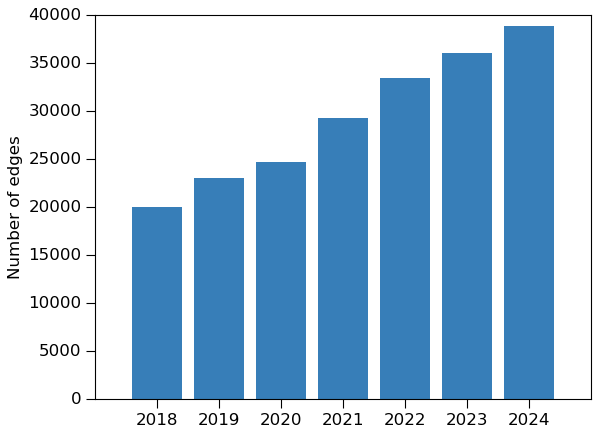

In [4]:
plt.bar([0, 1, 2, 3, 4, 5, 6], [data_oct_2018.shape[0], data_oct_2019.shape[0], data_oct_2020.shape[0], data_oct_2021.shape[0], data_oct_2022.shape[0], data_oct_2023.shape[0], data_oct_2024.shape[0]])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['2018', '2019', '2020', '2021', '2022', '2023', '2024'])
plt.ylabel('Number of edges')


# Consider only SIGNOR_ID

In [5]:
oct_2018_ids = data_oct_2018.SIGNOR_ID
oct_2019_ids = data_oct_2019.SIGNOR_ID
oct_2020_ids = data_oct_2020.SIGNOR_ID
oct_2021_ids = data_oct_2021.SIGNOR_ID
oct_2022_ids = data_oct_2022.SIGNOR_ID
oct_2023_ids = data_oct_2023.SIGNOR_ID
oct_2024_ids = data_oct_2024.SIGNOR_ID
jul_2025_ids = data_jul_2025.SIGNOR_ID

# Set of unique edges
oct_2018_ids_set = set(oct_2018_ids)
oct_2019_ids_set = set(oct_2019_ids)
oct_2020_ids_set = set(oct_2020_ids)
oct_2021_ids_set = set(oct_2021_ids)
oct_2022_ids_set = set(oct_2022_ids)
oct_2023_ids_set = set(oct_2023_ids)
oct_2024_ids_set = set(oct_2024_ids)
jul_2025_ids_set = set(jul_2025_ids)

In [6]:
removed_ids_2018_2019 = oct_2018_ids_set - oct_2018_ids_set.intersection(oct_2019_ids_set)
removed_ids_2019_2020 = oct_2019_ids_set - oct_2019_ids_set.intersection(oct_2020_ids_set)
removed_ids_2020_2021 = oct_2020_ids_set - oct_2020_ids_set.intersection(oct_2021_ids_set)
removed_ids_2021_2022 = oct_2021_ids_set - oct_2021_ids_set.intersection(oct_2022_ids_set)
removed_ids_2022_2023 = oct_2022_ids_set - oct_2022_ids_set.intersection(oct_2023_ids_set)
removed_ids_2023_2024 = oct_2023_ids_set - oct_2023_ids_set.intersection(oct_2024_ids_set)
removed_ids_2024_2025 = oct_2024_ids_set - oct_2024_ids_set.intersection(jul_2025_ids_set)

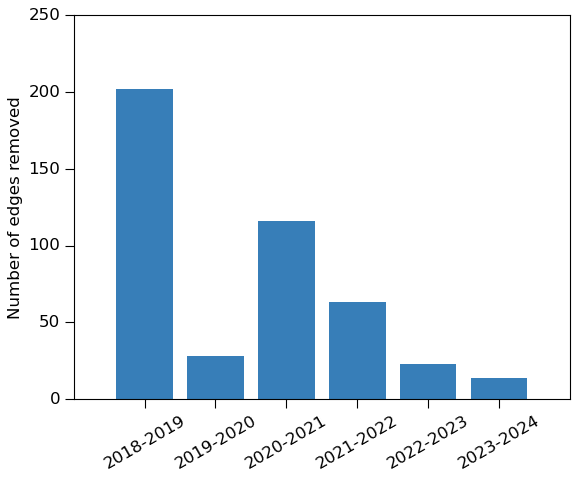

In [7]:
plt.bar([0, 1, 2, 3, 4, 5], [len(removed_ids_2018_2019), len(removed_ids_2019_2020), len(removed_ids_2020_2021), len(removed_ids_2021_2022), len(removed_ids_2022_2023), len(removed_ids_2023_2024)])
plt.xticks([0, 1, 2, 3, 4, 5], ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024'])
# Rotate x-axis labels
plt.xticks(rotation=30)
plt.ylabel('Number of edges removed')
plt.show()

# Consider also the source and target name

In [8]:
def find_reassigned_edges(removed_ids: set, old_data: pd.DataFrame, new_data: pd.DataFrame, consider_interaction: bool = True) -> List[Dict[str, Any]]:
    """
    Validate if edges marked as removed actually still exist in new data with different IDs.
    
    Args:
        removed_ids: Set of SIGNOR_IDs that appear to be removed
        old_data: DataFrame containing the old release data
        new_data: DataFrame containing the new release data
        consider_interaction: Whether to match on interaction type as well
    
    Returns:
        List of edges that still exist in new data despite being marked as removed
    """
    reassigned_edges = []
    
    for old_signor_id in removed_ids:
        # Step 1: Find the edge details in the old data using SIGNOR_ID
        if not pd.isna(old_signor_id):
            old_edge_row = old_data[old_data['SIGNOR_ID'] == old_signor_id]
        else:
            old_edge_row = old_data[old_data['SIGNOR_ID'].isna()]
        
        # Extract edge components from old data
        source_entity = old_edge_row['ENTITYA'].iloc[0]
        target_entity = old_edge_row['ENTITYB'].iloc[0]
        effect_type = old_edge_row['EFFECT'].iloc[0]

        # Step 2: Check if the same edge exists in the new data
        if consider_interaction:
            matching_edges = new_data[
                (new_data['ENTITYA'] == source_entity) & 
                (new_data['ENTITYB'] == target_entity) & 
                (new_data['EFFECT'] == effect_type)
            ]
            
            if not matching_edges.empty:
                reassigned_edges.append({
                    'old_signor_id': old_signor_id,
                    'source_entity': source_entity,
                    'target_entity': target_entity,
                    'effect_type': effect_type,
                    'new_signor_id': matching_edges['SIGNOR_ID'].iloc[0]
                })
        else:
            matching_edges = new_data[
                (new_data['ENTITYA'] == source_entity) & 
                (new_data['ENTITYB'] == target_entity)
            ]
            
            if not matching_edges.empty:
                reassigned_edges.append({
                    'old_signor_id': old_signor_id,
                    'source_entity': source_entity,
                    'target_entity': target_entity,
                    'new_signor_id': matching_edges['SIGNOR_ID'].iloc[0]
                })
    
    return reassigned_edges

In [9]:
reassigned_edges = find_reassigned_edges(removed_ids_2018_2019, data_oct_2018, data_oct_2019, consider_interaction=False)
# There are plenty edges with different SIGNOR_ID from different years.
print(len(reassigned_edges))
print(reassigned_edges[:5])

176
[{'old_signor_id': 'SIGNOR-235316', 'source_entity': 'ERK1/2', 'target_entity': 'CEBPA', 'new_signor_id': 'SIGNOR-235322'}, {'old_signor_id': 'SIGNOR-254611', 'source_entity': 'MYC', 'target_entity': 'ST3GAL4', 'new_signor_id': 'SIGNOR-253959'}, {'old_signor_id': 'SIGNOR-101566', 'source_entity': 'GSK3B', 'target_entity': 'NOTCH2', 'new_signor_id': 'SIGNOR-251254'}, {'old_signor_id': 'SIGNOR-252908', 'source_entity': 'DYRK1A', 'target_entity': 'FOXO', 'new_signor_id': 'SIGNOR-252907'}, {'old_signor_id': 'SIGNOR-251465', 'source_entity': 'GRK3', 'target_entity': 'CCR5', 'new_signor_id': 'SIGNOR-251463'}]


In [10]:
removed_ids_list = [removed_ids_2018_2019, removed_ids_2019_2020, removed_ids_2020_2021, removed_ids_2021_2022, removed_ids_2022_2023, removed_ids_2023_2024, removed_ids_2024_2025]
old_data_list = [data_oct_2018, data_oct_2019, data_oct_2020, data_oct_2021, data_oct_2022, data_oct_2023, data_oct_2024]
new_data_list = [data_oct_2019, data_oct_2020, data_oct_2021, data_oct_2022, data_oct_2023, data_oct_2024, data_jul_2025]

removed_edges_list = []
for i, removed_ids in enumerate(removed_ids_list):
    reassigned_edges = find_reassigned_edges(removed_ids, old_data_list[i], new_data_list[i], consider_interaction=False)
    # Delete the edges in the removed_ids that is in the reassigned_edges.
    for edge in reassigned_edges:
        if edge['old_signor_id'] in removed_ids:
            removed_ids.remove(edge['old_signor_id'])
    removed_edges_list.append(removed_ids)

In [11]:
removed_nums = [len(removed_ids) for removed_ids in removed_edges_list]
print('total removed edges:', sum(removed_nums))

total removed edges: 141


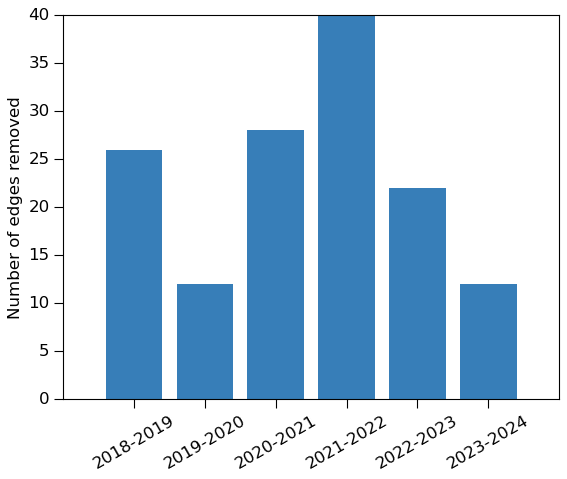

In [12]:
plt.bar([0, 1, 2, 3, 4, 5], [len(removed_edges_list[0]), len(removed_edges_list[1]), len(removed_edges_list[2]), len(removed_edges_list[3]), len(removed_edges_list[4]), len(removed_edges_list[5])])
plt.xticks([0, 1, 2, 3, 4, 5], ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024'])
# Rotate x-axis labels
plt.xticks(rotation=30)
plt.ylabel('Number of edges removed')
plt.show()

# Remove the edges that one of the node is completely removed from the 2025 graph.

In [13]:
removed_edges_with_node_exist_in_2025_list = [s.copy() for s in removed_edges_list]
for i, removed_edges in enumerate(removed_edges_list):
    for removed_id in list(removed_edges):
        old_edge_row = old_data_list[i][old_data_list[i]['SIGNOR_ID'] == removed_id]
        source_entity = old_edge_row['ENTITYA'].iloc[0]
        target_entity = old_edge_row['ENTITYB'].iloc[0]
        if (source_entity not in set(data_jul_2025['ENTITYA']).union(set(data_jul_2025['ENTITYB']))) or (target_entity not in set(data_jul_2025['ENTITYA']).union(set(data_jul_2025['ENTITYB']))):
            print(f"source: {source_entity}, targes: {target_entity}")
            removed_edges_with_node_exist_in_2025_list[i].remove(removed_id)

source: DHH, targes: PTCH2
source: STAT1A/STAT3/STAT5A/STAT5B, targes: Proliferation
source: HHIP, targes: DHH
source: STAT5B, targes: STAT1A/STAT3/STAT5A/STAT5B
source: STAT3, targes: STAT1A/STAT3/STAT5A/STAT5B
source: CBFβ-MYH11, targes: TP53
source: DHH, targes: PTCH1
source: cAMP, targes: PRKACA
source: dinoprost, targes: MYOD1
source: STAT1, targes: STAT1A/STAT3/STAT5A/STAT5B
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: STAT5A, targes: STAT1A/STAT3/STAT5A/STAT5B
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: RUNX2, targes: Osteoblast Differentiation
source: CTNNB1, targes: HIST1H3A
source: SDHD, targes: SDHC/SDHD
source: BAK/BAX, targes: Apoptosis
source: MCL1, targes: BAK/BAX
source: SDHB, targes: SDHA/SDHB
source: BCL2L11, targes: BAK/BAX
source: BAK/BAX, targes: DIABLO
source: BCR/ABL fusion, targes: BCR
source: BCL2L1, targ

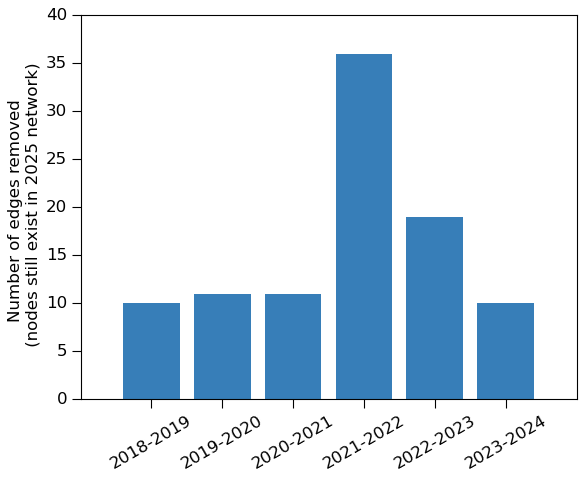

In [14]:
plt.bar([0, 1, 2, 3, 4, 5], [len(removed_edges_with_node_exist_in_2025_list[0]), len(removed_edges_with_node_exist_in_2025_list[1]), len(removed_edges_with_node_exist_in_2025_list[2]), len(removed_edges_with_node_exist_in_2025_list[3]), len(removed_edges_with_node_exist_in_2025_list[4]), len(removed_edges_with_node_exist_in_2025_list[5])])
plt.xticks([0, 1, 2, 3, 4, 5], ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024'])
# Rotate x-axis labels
plt.xticks(rotation=30)
plt.ylabel('Number of edges removed \n (nodes still exist in 2025 network)')
plt.show()

In [15]:
# Check if there is any removed edges that has been reassigned in the latest 2025 data
add_back_ids = []
for i, removed_edges in enumerate(removed_edges_with_node_exist_in_2025_list):
    reassigned_edges = find_reassigned_edges(removed_edges, old_data_list[i], data_jul_2025, consider_interaction=False)
    print(f"From {i}th removed edges, found {len(reassigned_edges)} reassigned edges in 2025 data.")
    if len(reassigned_edges) > 0:
        print(reassigned_edges)
        for edge in reassigned_edges:
            add_back_ids.append(edge['old_signor_id'])

From 0th removed edges, found 0 reassigned edges in 2025 data.
From 1th removed edges, found 0 reassigned edges in 2025 data.
From 2th removed edges, found 1 reassigned edges in 2025 data.
[{'old_signor_id': 'SIGNOR-170134', 'source_entity': 'TRPM7', 'target_entity': 'EEF2K', 'new_signor_id': 'SIGNOR-277923'}]
From 3th removed edges, found 0 reassigned edges in 2025 data.
From 4th removed edges, found 0 reassigned edges in 2025 data.
From 5th removed edges, found 0 reassigned edges in 2025 data.
From 6th removed edges, found 0 reassigned edges in 2025 data.


# Save the removed edges as a csv table

In [16]:
file_names = ['Oct2018_release', 'Oct2019_release', 'Oct2020_release', 'Oct2021_release', 'Oct2022_release', 'Oct2023_release', 'Oct2024_release', 'Jul2025_release']
data_list = [data_oct_2018, data_oct_2019, data_oct_2020, data_oct_2021, data_oct_2022, data_oct_2023, data_oct_2024, data_jul_2025]

all_removed_edges_data = []

for i, removed_edges in enumerate(removed_edges_with_node_exist_in_2025_list):
    for removed_id in removed_edges:
        old_edge_row = old_data_list[i][old_data_list[i]['SIGNOR_ID'] == removed_id]
        if not old_edge_row.empty and removed_id not in add_back_ids:
            edge_dict = old_edge_row.iloc[0].to_dict()
            edge_dict['source_release'] = file_names[i]  # Add source release column
            all_removed_edges_data.append(edge_dict)

# Create one big DataFrame with all removed edges
all_removed_edges_df = pd.DataFrame(all_removed_edges_data)

# Save to single CSV file
all_removed_edges_df.to_csv('all_removed_edges_with_sources.csv', index=False)

print(f"Saved {len(all_removed_edges_df)} removed edges to 'all_removed_edges_with_sources.csv'")

Saved 97 removed edges to 'all_removed_edges_with_sources.csv'


In [17]:
all_removed_edges_df.shape

(97, 28)

In [17]:
all_removed_edges_df

,ENTITYA,TYPEA,IDA,DATABASEA,ENTITYB,TYPEB,IDB,DATABASEB,EFFECT,MECHANISM,...,MODASEQ,MODIFICATIONB,MODBSEQ,PMID,DIRECT,NOTES,ANNOTATOR,SENTENCE,SIGNOR_ID,source_release
0,TP53,protein,P04637,UNIPROT,BCL2L1,protein,Q07817,UNIPROT,down-regulates activity,binding,...,NaN,NaN,NaN,16455050,t,NaN,lperfetto,It has been shown that tp53 can directly bind ...,SIGNOR-144163,Oct2018_release
1,DAB2IP,protein,Q5VWQ8,UNIPROT,Apoptosis,phenotype,SIGNOR-PH2,SIGNOR,up-regulates,NaN,...,NaN,NaN,NaN,27858941,f,NaN,miannu,DAB2IP inactivation promotes tumor growth and ...,SIGNOR-254777,Oct2018_release
2,CRTC2,protein,Q53ET0,UNIPROT,AKT1,protein,P31749,UNIPROT,up-regulates,phosphorylation,...,NaN,NaN,NaN,21798082,t,NaN,gcesareni,"Positive feedback involves mtorc2, which phosp...",SIGNOR-175304,Oct2018_release
3,IRF3,protein,Q14653,UNIPROT,Inflammation,phenotype,SIGNOR-PH12,SIGNOR,up-regulates,NaN,...,NaN,NaN,NaN,16699525,f,NaN,lperfetto,"Similarly, exogenous expression of wild-type P...",SIGNOR-252258,Oct2018_release
4,SMAD9,protein,O15198,UNIPROT,Differentiation,phenotype,SIGNOR-PH37,SIGNOR,up-regulates,NaN,...,NaN,NaN,NaN,23993924,f,NaN,flangone,Engagement of BMP4-mediated signaling in adult...,SIGNOR-255258,Oct2018_release
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,STAT1,protein,P42224,UNIPROT,JAK1/STAT1/STAT3,complex,SIGNOR-C120,SIGNOR,form complex,binding,...,NaN,NaN,NaN,15284024,t,NaN,lperfetto,Stimulation of EGFR induces Tyr701 phosphoryla...,SIGNOR-235612,Oct2023_release
93,SETD1A,protein,O15047,UNIPROT,MLL/SET subcomplex,complex,SIGNOR-C87,SIGNOR,form complex,binding,...,NaN,NaN,NaN,24680668,t,NaN,miannu,Dimethylation of h3k4 requires a sub-complex i...,SIGNOR-268797,Oct2023_release
94,CD3D,protein,P04234,UNIPROT,TCR,complex,SIGNOR-C153,SIGNOR,form complex,binding,...,NaN,NaN,NaN,12507424,t,NaN,miannu,The T cell receptor-CD3 complex (TCR-CD3) serv...,SIGNOR-269471,Oct2023_release
95,CyclinA2/CDK2,complex,SIGNOR-C83,SIGNOR,CABLES1,protein,Q8TDN4,UNIPROT,unknown,phosphorylation,...,NaN,NaN,NaN,11733001,t,NaN,llicata,"Here, we report that Ser274 of p70ik3-1 is pho...",SIGNOR-250756,Oct2023_release


In [19]:
# Protein-protein interactions only
protein_removed_edges_df = all_removed_edges_df[(all_removed_edges_df['TYPEA'] == 'protein') & (all_removed_edges_df['TYPEB'] == 'protein')]
print(f"Number of protein-protein removed edges: {len(protein_removed_edges_df)}")

Number of protein-protein removed edges: 30


In [30]:
# Find duplicate edges based on ENTITYA, ENTITYB, and EFFECT columns
duplicate_edges = protein_removed_edges_df[protein_removed_edges_df.duplicated(subset=['ENTITYA', 'ENTITYB', 'EFFECT'], keep=False)]
print(f"Number of duplicate removed edges: {len(duplicate_edges)}")


Number of duplicate removed edges: 8


In [31]:
duplicate_edges

,ENTITYA,TYPEA,IDA,DATABASEA,ENTITYB,TYPEB,IDB,DATABASEB,EFFECT,MECHANISM,...,MODASEQ,MODIFICATIONB,MODBSEQ,PMID,DIRECT,NOTES,ANNOTATOR,SENTENCE,SIGNOR_ID,source_release
10,GNAT1,protein,P11488,UNIPROT,ADCY1,protein,Q08828,UNIPROT,down-regulates,binding,...,NaN,NaN,NaN,17419683,t,NaN,gcesareni,Members of the gi family are linked with reduc...,SIGNOR-153923,Oct2019_release
12,GNAT1,protein,P11488,UNIPROT,ADCY1,protein,Q08828,UNIPROT,down-regulates,binding,...,NaN,NaN,NaN,8327893,t,NaN,gcesareni,Members of the gi family are linked with reduc...,SIGNOR-38137,Oct2019_release
15,GNAO1,protein,P09471,UNIPROT,ADCY1,protein,Q08828,UNIPROT,down-regulates,binding,...,NaN,NaN,NaN,17419683,t,NaN,gcesareni,Members of the gi family are linked with reduc...,SIGNOR-153467,Oct2019_release
19,GNAO1,protein,P09471,UNIPROT,ADCY1,protein,Q08828,UNIPROT,down-regulates,binding,...,NaN,NaN,NaN,8327893,t,NaN,gcesareni,Members of the gi family are linked with reduc...,SIGNOR-38079,Oct2019_release
23,AKT1,protein,P31749,UNIPROT,PPP1CA,protein,P62136,UNIPROT,down-regulates,phosphorylation,...,NaN,NaN,NaN,17202132,t,NaN,gcesareni,Ir-induced pp1 activation in the nucleus may b...,SIGNOR-252498,Oct2020_release
25,AKT1,protein,P31749,UNIPROT,PPP1CA,protein,P62136,UNIPROT,down-regulates,phosphorylation,...,NaN,NaN,NaN,12202491,t,NaN,gcesareni,Ir-induced pp1 activation in the nucleus may b...,SIGNOR-92257,Oct2020_release
69,AURKA,protein,O14965,UNIPROT,AR,protein,P10275,UNIPROT,up-regulates activity,phosphorylation,...,NaN,NaN,NaN,20713353,t,NaN,miannu,Phosphorylation and activation of androgen rec...,SIGNOR-259827,Oct2022_release
71,AURKA,protein,O14965,UNIPROT,AR,protein,P10275,UNIPROT,up-regulates activity,phosphorylation,...,NaN,NaN,NaN,20713353,t,NaN,miannu,Phosphorylation and activation of androgen rec...,SIGNOR-259828,Oct2022_release


In [18]:
# Workflow: 
# 1. I first identified the removed edges between each consecutive year by considering only SIGNOR_ID.
# 2. Since SIGNOR_IDs can change for the same edge (same ENTITYA, ENTITYB, EFFECT), I then checked whether any of the removed edges actually still existed in the following year's data with different SIGNOR_IDs.
# 3. I removed those "reassigned" edges from the removed edges list.
# 4. I then further filtered the removed edges to keep only those edges whose nodes still exist in the latest 2025 data.
# 5. Finally, I checked again whether any of the removed edges had been added back in the 2025 data.
# NOTE:
# 1. There are plenty of ribosomal subunit related edges being removed in 2021-2022 data.
# 2. There are only one removed edge being added back in 2025 data: {'old_signor_id': 'SIGNOR-170134', 'source_entity': 'TRPM7', 'target_entity': 'EEF2K', 'new_signor_id': 'SIGNOR-277923'}

# Positive edges

In [19]:
# Only consider the protein-protein interactions
data_jul_2025_ppi = data_jul_2025[(data_jul_2025['TYPEA'] == 'protein') & (data_jul_2025['TYPEB'] == 'protein')]
print(f"Number of protein-protein interactions in Signor Jul 2025 data: {data_jul_2025_ppi.shape[0]}")

Number of protein-protein interactions in Signor Jul 2025 data: 25195


In [20]:
# Get candidate source nodes from removed edges. 
# The idea is to find positive edges which contains nodes that appear in removed edges. 
# The reason is that those nodes might be more carefully human curated thus the remaining positive edges are more reliable.
candidate_source_nodes = set()
for row in all_removed_edges_df.itertuples():
    if row.TYPEA != 'protein' or row.TYPEB != 'protein':
        continue
    source_entity = row.ENTITYA
    target_entity = row.ENTITYB
    candidate_source_nodes.add(source_entity)
    candidate_source_nodes.add(target_entity)

In [21]:
index_list = []
for node in list(candidate_source_nodes):
    indeces = data_jul_2025_ppi[(data_jul_2025_ppi['ENTITYA'] == node) | (data_jul_2025_ppi['ENTITYB'] == node)]
    index_list.extend(indeces.index.tolist())

In [22]:
data_jul_2025_ppi_subset = data_jul_2025_ppi.loc[index_list].drop_duplicates()
print(f"Number of candidate positive edges: {data_jul_2025_ppi_subset.shape[0]}")

Number of candidate positive edges: 3757


## Use llm to read the SENTENCE and determine whether the interaction is really described in the SENTENCE

In [23]:
def query_llm(
    prompt: str,
    api_url: str = "http://localhost:8080",
    **kwargs
) -> dict:
    """Query the LLM API with the given prompt and parameters."""
    url = f"{api_url}/completion"

    payload = {
        "prompt": prompt,
        "temperature": kwargs.get("temperature", 0.1),
        "n_predict": kwargs.get("max_tokens", -1),
        "stream": False,
        "n_probs": kwargs.get("n_probs", 0),
        "post_sampling_probs": True,
        "grammar": kwargs.get("grammar", ""),
        "json_schema": kwargs.get("json_schema", None),
    }

    for key, value in kwargs.items():
        if key not in ["temperature", "max_tokens", "n_probs", "grammar", "json_schema"]:
            payload[key] = value

    try:
        response = requests.post(url, json=payload, timeout=300)
        response.raise_for_status()
        result = response.json()
        return result
    except requests.exceptions.RequestException as e:
        raise RuntimeError(f"API request failed: {e}")


def extract_json_from_gpt_oss(text):
    """Extract JSON from GPT-OSS-120B response with special tokens."""
    if '{"answer"' in text:
        start = text.rfind('{"answer"')
        end = text.find('}', start) + 1
        if end > start:
            return text[start:end]
    return text


def get_interaction_prompt(source: str, target: str, interaction: str) -> str:
    """Convert interaction type to natural language prompt."""
    if interaction == 'down-regulates':
        return f"{source} down-regulate {target}"
    elif interaction == 'down-regulates activity':
        return f"{source} inhibit the activity of {target}"
    elif interaction == 'form complex':
        return f"{source} form a complex with {target}"
    elif interaction == 'up-regulates':
        return f"{source} up-regulate {target}"
    elif interaction == 'up-regulates activity':
        return f"{source} activate {target}"
    elif interaction == 'up-regulates quantity':
        return f"{source} increase {target} expression?"
    elif interaction == 'up-regulates quantity by expression':
        return f"{source} increase {target} expression?"
    else:  # handles 'unknown' and any other unexpected interactions
        return f"{source} interact with {target}"


# JSON schema for structured output
json_schema = {
    "type": "object",
    "properties": {
        "answer": {
            "type": "string",
            "enum": ["Yes", "No"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["answer", "reasoning"]
}

# System prompt for LLM
system_prompt = """You are a molecular biologist expert in biological interactions. 
You need to determine whether the following sentence accurately describes the specified interaction between two entities.
You MUST respond with ONLY valid JSON in this exact format:
{"answer":"Yes","reasoning":"your detailed reasoning here"}

Rules:
- answer must be exactly "Yes" or "No"
- reasoning must be a single line string (escape quotes with \\")
- Do NOT include any text before or after the JSON
- Do NOT use markdown code blocks"""

In [24]:
# # Main processing loop: query LLM for positive edges
# target_size = len(all_removed_edges_df[(all_removed_edges_df['TYPEA'] == 'protein') & (all_removed_edges_df['TYPEB'] == 'protein')])
# count = 0
# idxs = list(range(len(data_jul_2025_ppi_subset)))
# positive_edges_df = []

# while count < target_size:
#     index = np.random.choice(idxs, replace=False)
#     source = data_jul_2025_ppi_subset['ENTITYA'].iloc[index]
#     target = data_jul_2025_ppi_subset['ENTITYB'].iloc[index]
#     interaction = data_jul_2025_ppi_subset['EFFECT'].iloc[index]
#     sentence = data_jul_2025_ppi_subset['SENTENCE'].iloc[index]
    
#     # Get interaction prompt
#     interaction_prompt = get_interaction_prompt(source, target, interaction)
    
#     # Build prompt and query LLM
#     user_prompt = f"""Sentence: {sentence}
# Interaction: {interaction_prompt}
# Respond with JSON only:"""
#     prompt = f"{system_prompt}\n\n{user_prompt}"
    
#     # Query LLM
#     result = query_llm(prompt, json_schema=json_schema, max_tokens=-1)
#     response_text = result['content'].strip()
#     cleaned = extract_json_from_gpt_oss(response_text)
    
#     # Parse response
#     try:
#         data = json.loads(cleaned)
#         answer = data['answer']
#         reasoning = data['reasoning']
        
#         if answer == 'Yes':
#             count += 1
#             print(f"Count of 'Yes' answers: {count}/{target_size}")
#             edge_dict = data_jul_2025_ppi_subset.iloc[index].to_dict()
#             edge_dict['llm_reasoning'] = reasoning
#             positive_edges_df.append(edge_dict)
#     except json.JSONDecodeError:
#         print(f"✗ Parse failed. Raw: {response_text[:200]}")

# # Save results
# positive_edges_df = pd.DataFrame(positive_edges_df)
# positive_edges_df.to_csv('positive_edges_with_llm_reasoning.csv', index=False)
# print(f"Saved {len(positive_edges_df)} positive edges to 'positive_edges_with_llm_reasoning.csv'")

In [ ]:
# Main processing loop: query LLM for all edges
results_list = []

for index in tqdm(range(len(data_jul_2025_ppi_subset))):
    source = data_jul_2025_ppi_subset['ENTITYA'].iloc[index]
    target = data_jul_2025_ppi_subset['ENTITYB'].iloc[index]
    interaction = data_jul_2025_ppi_subset['EFFECT'].iloc[index]
    sentence = data_jul_2025_ppi_subset['SENTENCE'].iloc[index]
    
    # Get interaction prompt
    interaction_prompt = get_interaction_prompt(source, target, interaction)
    
    # Build prompt and query LLM
    user_prompt = f"""Sentence: {sentence}
Interaction: {interaction_prompt}
Respond with JSON only:"""
    prompt = f"{system_prompt}\n\n{user_prompt}"
    
    # Query LLM
    try:
        result = query_llm(prompt, json_schema=json_schema, max_tokens=-1)
        response_text = result['content'].strip()
        cleaned = extract_json_from_gpt_oss(response_text)
        
        # Parse response
        data = json.loads(cleaned)
        answer = data['answer']
        reasoning = data['reasoning']
        
        # Append answer and reasoning to the row
        edge_dict = data_jul_2025_ppi_subset.iloc[index].to_dict()
        edge_dict['llm_answer'] = answer
        edge_dict['llm_reasoning'] = reasoning
        results_list.append(edge_dict)
        
        if answer == 'Yes':
            print(f"Index {index}: Yes ({len([r for r in results_list if r['llm_answer'] == 'Yes'])}/{len(results_list)})")
            
    except (json.JSONDecodeError, KeyError) as e:
        print(f"✗ Error at index {index}: {e}. Raw: {response_text[:200]}")
        # Still append the row with error information
        edge_dict = data_jul_2025_ppi_subset.iloc[index].to_dict()
        edge_dict['llm_answer'] = 'Error'
        edge_dict['llm_reasoning'] = f"Parse error: {str(e)}"
        results_list.append(edge_dict)

# Save results
results_df = pd.DataFrame(results_list)
results_df.to_csv('positive_edges_with_llm_reasoning_full.csv', index=False)
print(f"\nSaved {len(results_df)} edges to 'positive_edges_with_llm_reasoning_full.csv'")
print(f"Total 'Yes' answers: {len(results_df[results_df['llm_answer'] == 'Yes'])}")
print(f"Total 'No' answers: {len(results_df[results_df['llm_answer'] == 'No'])}")
print(f"Total errors: {len(results_df[results_df['llm_answer'] == 'Error'])}")

  0%|          | 0/3757 [00:00<?, ?it/s]

  0%|          | 1/3757 [00:04<4:11:24,  4.02s/it]

Index 0: Yes (1/1)


  0%|          | 2/3757 [00:07<3:46:11,  3.61s/it]

Index 1: Yes (2/2)


...

Index 920: Yes (682/921)


 25%|██▍       | 922/3757 [59:20<3:28:12,  4.41s/it]

Index 921: Yes (683/922)


 25%|██▍       | 923/3757 [59:25<3:28:11,  4.41s/it]

Index 922: Yes (684/923)
